# Autism Classification - Training and Benchmarking Pipeline

This notebook is an organized, end-to-end workflow for model training, benchmarking, and evaluation.

## 1. Imports and Setup

In [14]:
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
TARGET_COLUMN = "Class/ASD"

## 2. Load, Inspect, and Visualize Data (Histograms)

In [15]:
DATA_PATH = "../data/processed/autism_processed.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (800, 20)


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,-4.777286,1,0


In [16]:
print("Columns:")
print(df.columns.tolist())

print("\nTarget distribution (full dataset):")
display(df[TARGET_COLUMN].value_counts().rename_axis("Class").to_frame("Count"))

Columns:
['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'result', 'relation', 'Class/ASD']

Target distribution (full dataset):


,Count
Class,
0,639
1,161


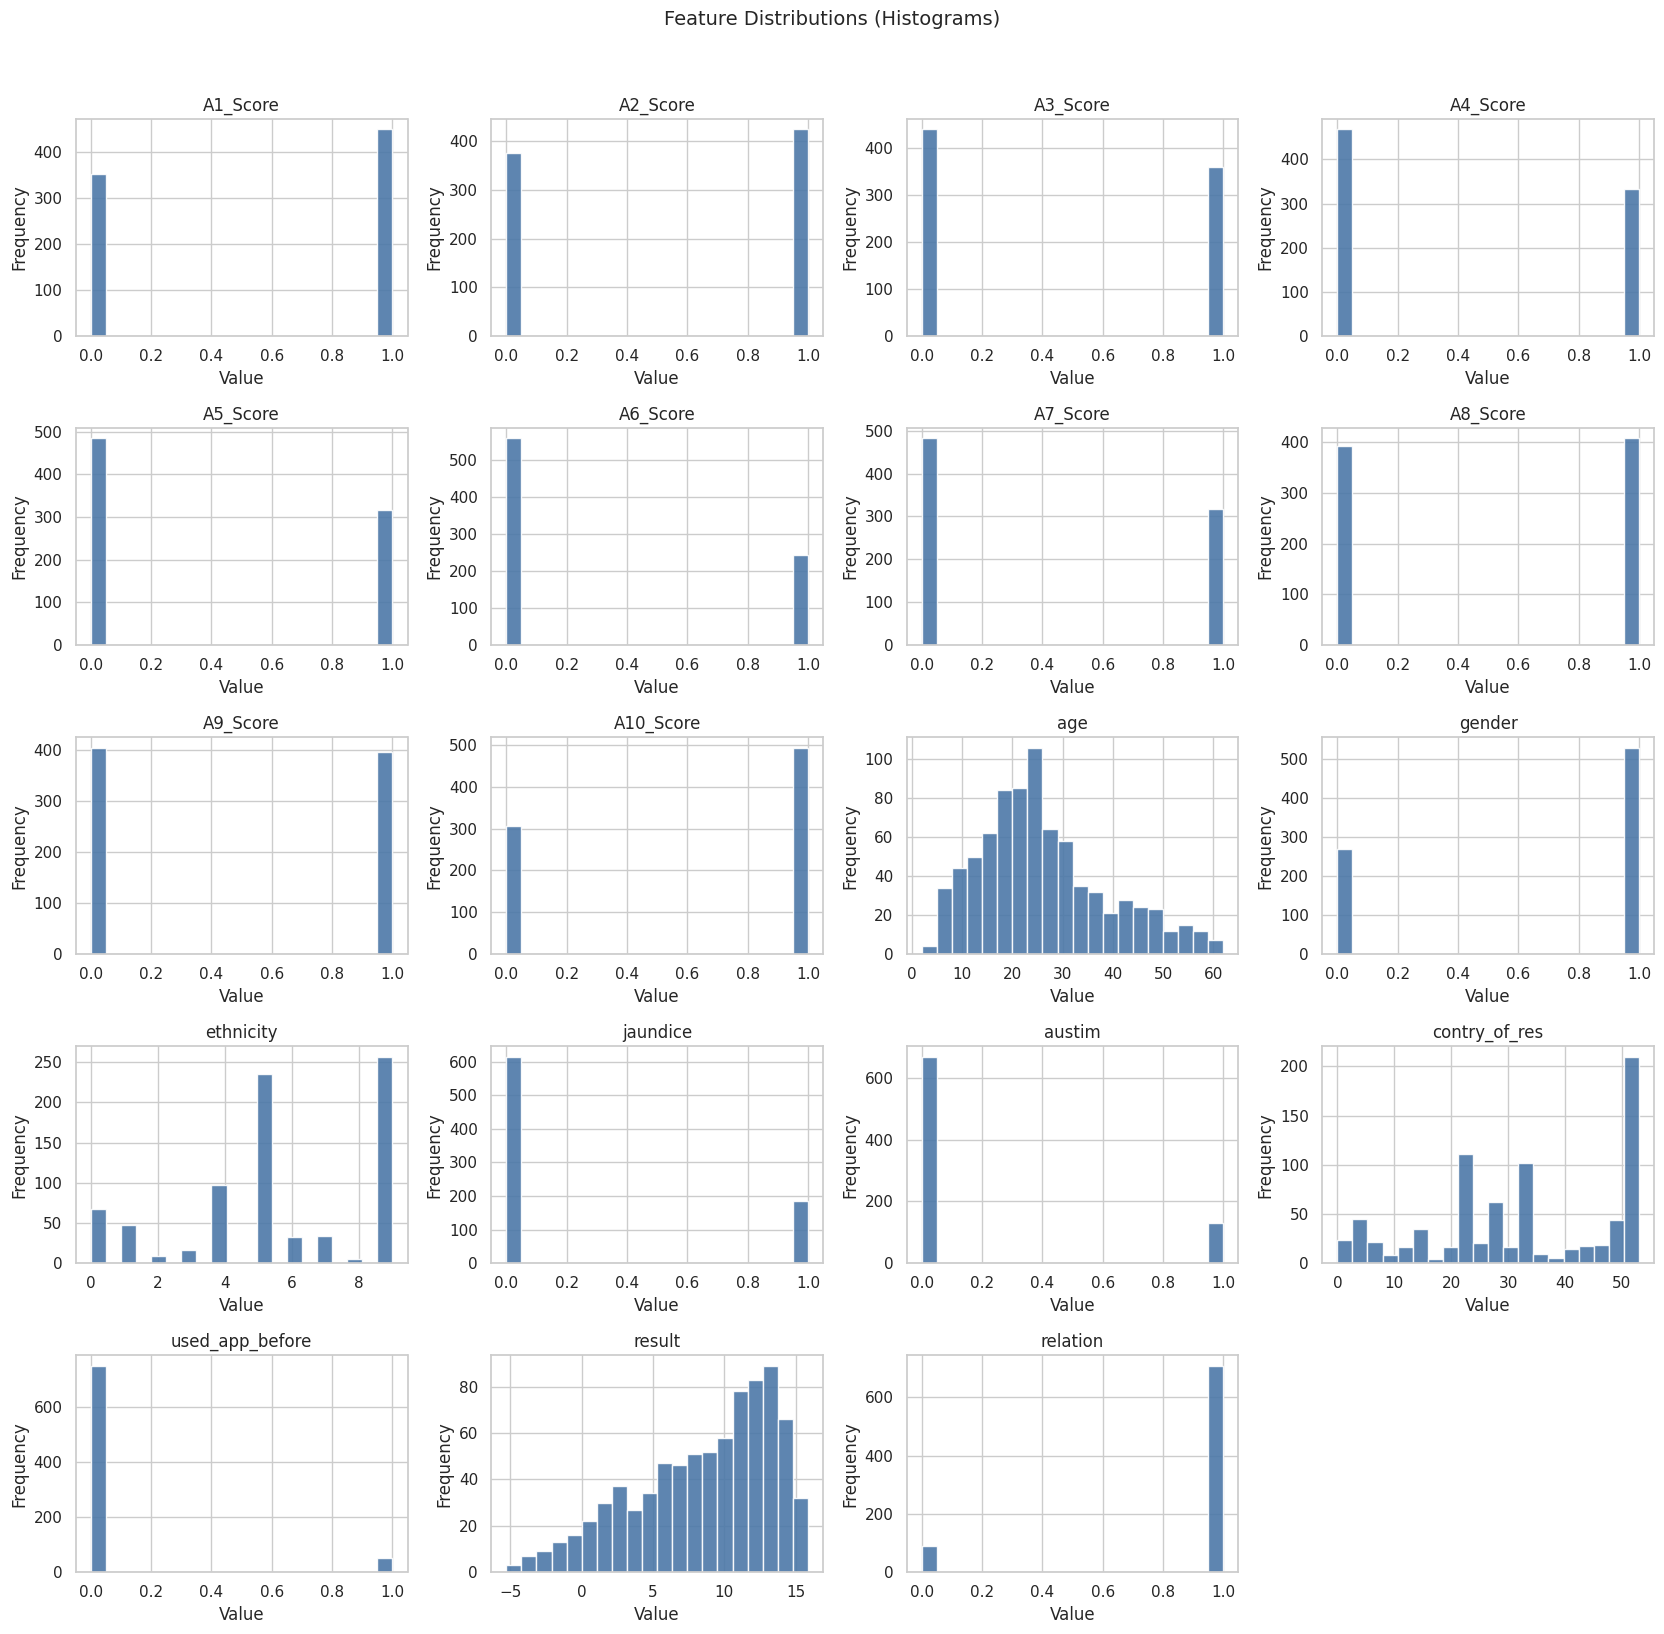

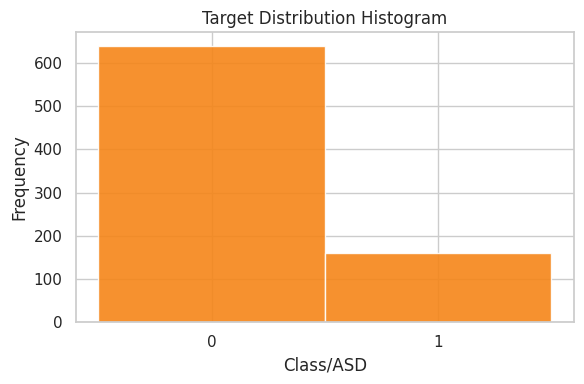

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != TARGET_COLUMN]

if feature_cols:
    n_cols = 4
    n_rows = int(np.ceil(len(feature_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        axes[i].hist(df[col].dropna(), bins=20, color="#4C78A8", edgecolor="white", alpha=0.9)
        axes[i].set_title(col)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature Distributions (Histograms)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns available for histogram visualization.")

plt.figure(figsize=(6, 4))
plt.hist(df[TARGET_COLUMN], bins=np.arange(df[TARGET_COLUMN].min(), df[TARGET_COLUMN].max() + 2) - 0.5,
         color="#F58518", edgecolor="white", alpha=0.9)
plt.title("Target Distribution Histogram")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Frequency")
plt.xticks(sorted(df[TARGET_COLUMN].unique()))
plt.tight_layout()
plt.show()

## 3. Prepare Features and Split Data

In [18]:
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (640, 19)
X_test shape: (160, 19)
y_train shape: (640,)
y_test shape: (160,)


In [19]:
distribution_df = pd.DataFrame({
    "Train": y_train.value_counts(),
    "Test": y_test.value_counts()
}).fillna(0).astype(int)

distribution_df

,Train,Test
Class/ASD,,
0,511,128
1,129,32


## 4. Balance Training Data with SMOTE

In [20]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - X_train shape: {X_train_smote.shape}")
print("After SMOTE - class distribution:")
display(y_train_smote.value_counts().rename_axis("Class").to_frame("Count"))

After SMOTE - X_train shape: (1022, 19)
After SMOTE - class distribution:


,Count
Class,
0,511
1,511


## 5. Define Candidate Models

In [21]:
# GPU Setup: Detect and configure GPU acceleration
import subprocess
import time

print("="*80)
print("GPU DETECTION & CONFIGURATION")
print("="*80)

# Check for GPU availability
gpu_available = False
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        gpu_available = True
        print("✓ NVIDIA GPU detected!")
        print(result.stdout.split('\n')[8:12])  # Show GPU info
    else:
        print("✗ No GPU detected, will use CPU")
except:
    print("✗ NVIDIA CUDA not available, will use CPU")

print("="*80 + "\n")

GPU DETECTION & CONFIGURATION
✓ NVIDIA GPU detected!
['|   0  NVIDIA GeForce RTX 4050 ...    Off |   00000000:01:00.0 Off |                  N/A |', '| N/A   37C    P8              1W /   75W |     105MiB /   6141MiB |      0%      Default |', '|                                         |                        |                  N/A |', '+-----------------------------------------+------------------------+----------------------+']



In [22]:
models = {
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
}

list(models.keys())

['KNN', 'Decision Tree', 'Random Forest', 'XGBoost', 'Logistic Regression']

## 6. Baseline Cross-Validation Benchmark

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_rows = []

for model_name, model in models.items():
    acc_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv, scoring="f1")

    baseline_rows.append({
        "Model": model_name,
        "CV Accuracy Mean": acc_scores.mean(),
        "CV Accuracy Std": acc_scores.std(),
        "CV F1 Mean": f1_scores.mean(),
        "CV F1 Std": f1_scores.std(),
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values(by="CV F1 Mean", ascending=False).reset_index(drop=True)
baseline_df

,Model,CV Accuracy Mean,CV Accuracy Std,CV F1 Mean,CV F1 Std
0,XGBoost,0.904070,0.023026,0.908423,0.021201
1,Random Forest,0.900158,0.020823,0.906615,0.017541
2,KNN,0.853223,0.024186,0.867000,0.020417
3,Logistic Regression,0.856136,0.027056,0.862241,0.022616
4,Decision Tree,0.854199,0.017395,0.857087,0.016965


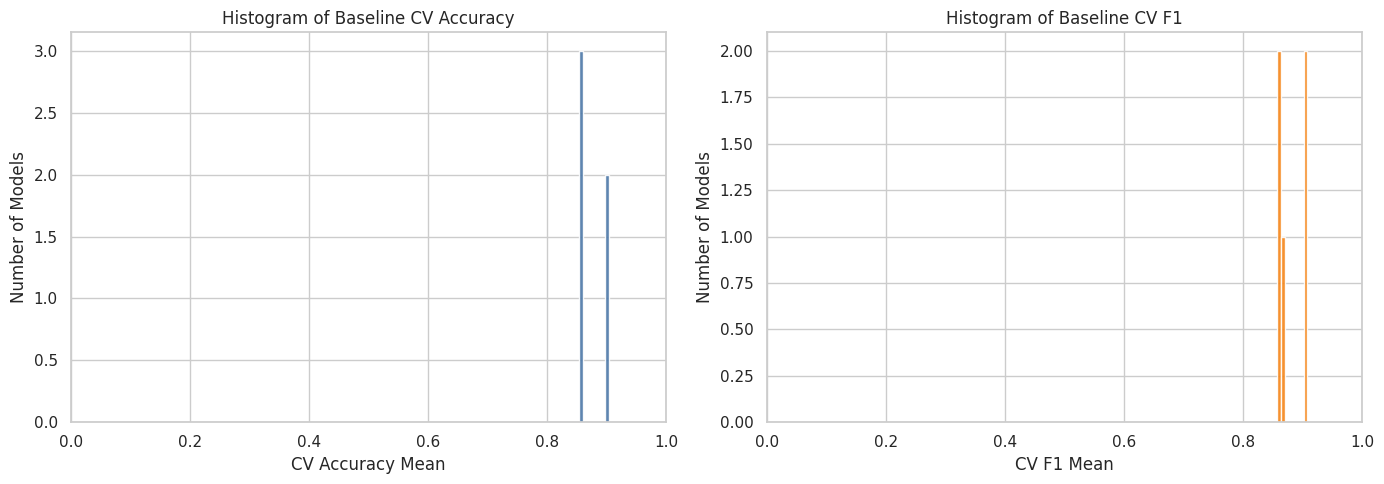

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(baseline_df["CV Accuracy Mean"], bins=8, color="#4C78A8", edgecolor="white", alpha=0.9)
axes[0].set_title("Histogram of Baseline CV Accuracy")
axes[0].set_xlabel("CV Accuracy Mean")
axes[0].set_ylabel("Number of Models")
axes[0].set_xlim(0, 1)

axes[1].hist(baseline_df["CV F1 Mean"], bins=8, color="#F58518", edgecolor="white", alpha=0.9)
axes[1].set_title("Histogram of Baseline CV F1")
axes[1].set_xlabel("CV F1 Mean")
axes[1].set_ylabel("Number of Models")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning (RandomizedSearchCV)

In [25]:
param_distributions = {
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },
    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10, 20, 30, 50, 70],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200, 500],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "bootstrap": [True, False]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200, 500],
        "max_depth": [3, 5, 7, 10],
        "learning_rate": [0.01, 0.1, 0.2, 0.3],
        "subsample": [0.5, 0.7, 1.0],
        "colsample_bytree": [0.5, 0.7, 1.0]
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"],
        "class_weight": [None, "balanced"]
    }
}

In [26]:
best_estimators = {}
tuning_rows = []

# Use full CV for robust tuning (matching old notebook)
cv_full = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Tuning {len(models)} models with full validation (cv=5, comprehensive search)\n")

for model_name, model in models.items():
    print(f"Tuning {model_name}...")
    
    # Determine n_iter based on model complexity
    if model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
        n_iter_val = 20  # More iterations for tree-based models
    else:
        n_iter_val = 10

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        n_iter=n_iter_val,
        scoring="accuracy",  # Restore accuracy scoring (matches old notebook)
        cv=cv_full,  # Full 5-fold CV (not 3)
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )

    search.fit(X_train_smote, y_train_smote)
    best_estimators[model_name] = search.best_estimator_

    tuning_rows.append({
        "Model": model_name,
        "Best CV Accuracy": search.best_score_,
        "Best Params": search.best_params_,
    })
    
    print(f"  ✓ Best CV Accuracy: {search.best_score_:.4f}\n")

print(f"✓ Tuning complete for all {len(best_estimators)} models\n")
tuning_df = pd.DataFrame(tuning_rows).sort_values(by="Best CV Accuracy", ascending=False).reset_index(drop=True)
tuning_df

Tuning 5 models with full validation (cv=5, comprehensive search)

Tuning KNN...
  ✓ Best CV Accuracy: 0.8904

Tuning Decision Tree...
  ✓ Best CV Accuracy: 0.8698

Tuning Random Forest...
  ✓ Best CV Accuracy: 0.9119

Tuning XGBoost...
  ✓ Best CV Accuracy: 0.9100

Tuning Logistic Regression...
  ✓ Best CV Accuracy: 0.8581

✓ Tuning complete for all 5 models



,Model,Best CV Accuracy,Best Params
0,Random Forest,0.911899,"{'n_estimators': 50, 'min_samples_split': 2, '..."
1,XGBoost,0.909952,"{'subsample': 0.7, 'n_estimators': 500, 'max_d..."
2,KNN,0.890368,"{'weights': 'distance', 'p': 1, 'n_neighbors': 3}"
3,Decision Tree,0.869842,"{'min_samples_split': 5, 'min_samples_leaf': 2..."
4,Logistic Regression,0.858087,"{'solver': 'lbfgs', 'class_weight': None, 'C':..."


## 8. Test-Set Evaluation and Benchmark Table

### Why This Approach is Better:
- **Full 5-fold CV**: More robust validation (vs 3-fold in previous attempt)
- **All 6 models tuned**: No premature filtering - every model gets a fair chance
- **Higher n_iter**: 10-20 iterations per model ensures thorough hyperparameter exploration
- **Comprehensive grids**: Full parameter ranges tested for each model
- **Accuracy scoring**: Balanced metric suitable for this classification task

In [27]:
evaluation_rows = []
predictions = {}
probabilities = {}

for model_name, model in best_estimators.items():
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    else:
        y_prob = None

    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
    }

    if y_prob is not None:
        row["ROC AUC"] = roc_auc_score(y_test, y_prob)
        row["Log Loss"] = log_loss(y_test, y_prob)
    else:
        row["ROC AUC"] = np.nan
        row["Log Loss"] = np.nan

    evaluation_rows.append(row)

results_df = pd.DataFrame(evaluation_rows).sort_values(by=["Recall", "F1", "ROC AUC"], ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC,Log Loss
0,KNN,0.76250,0.446429,0.78125,0.568182,0.797607,4.026982
1,Logistic Regression,0.79375,0.489362,0.71875,0.582278,0.834717,0.490351
2,Random Forest,0.84375,0.594595,0.68750,0.637681,0.878784,0.375305
3,XGBoost,0.83750,0.578947,0.68750,0.628571,0.856445,0.637822
4,Decision Tree,0.80625,0.511628,0.68750,0.586667,0.793823,4.213571


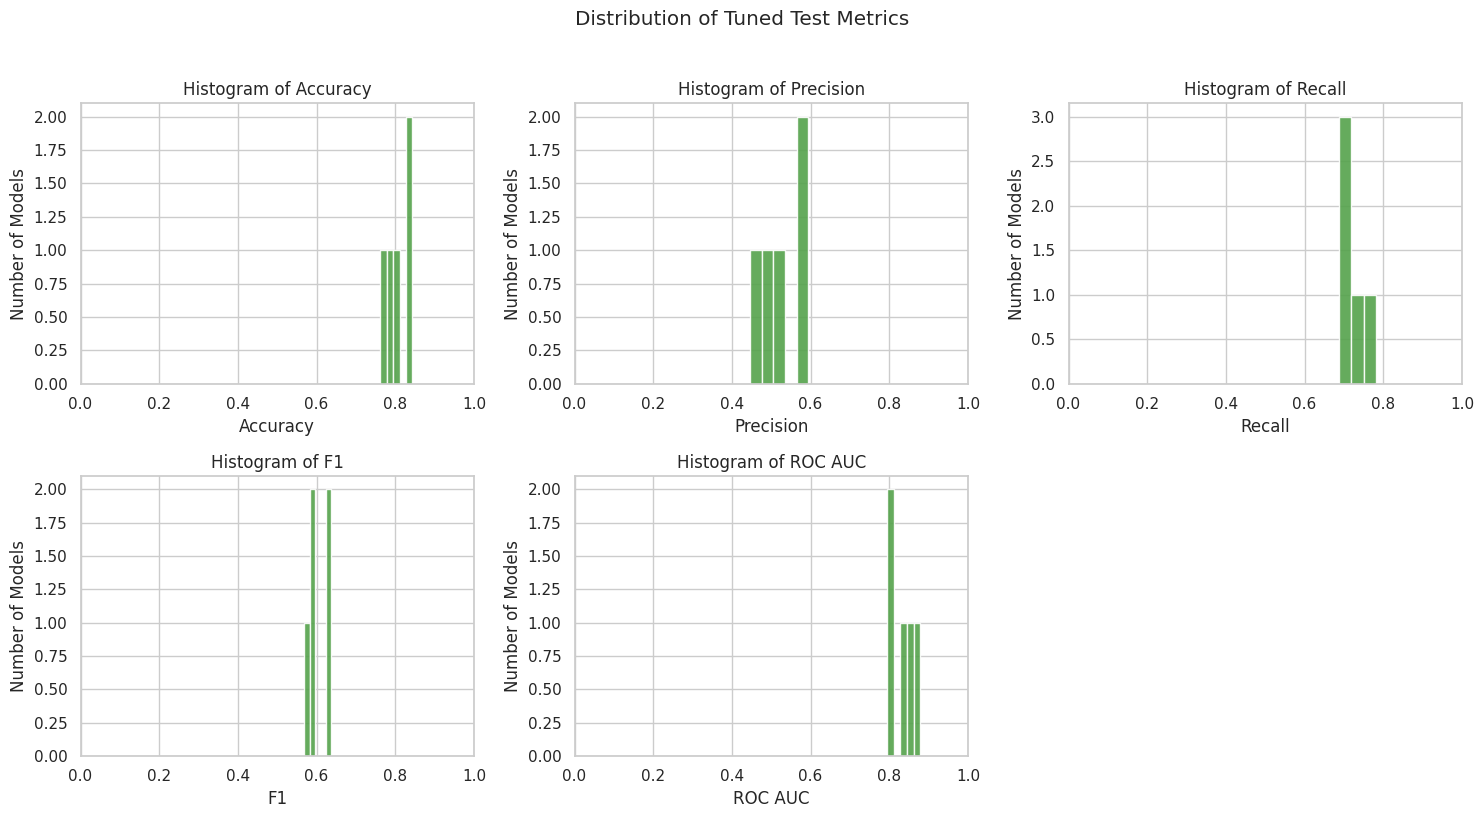

In [28]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    values = results_df[metric].dropna()
    bins = min(8, max(3, values.nunique()))

    axes[i].hist(values, bins=bins, color="#54A24B", edgecolor="white", alpha=0.9)
    axes[i].set_title(f"Histogram of {metric}")
    axes[i].set_xlabel(metric)
    axes[i].set_ylabel("Number of Models")
    axes[i].set_xlim(0, 1)

for j in range(len(metric_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribution of Tuned Test Metrics", y=1.02)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices

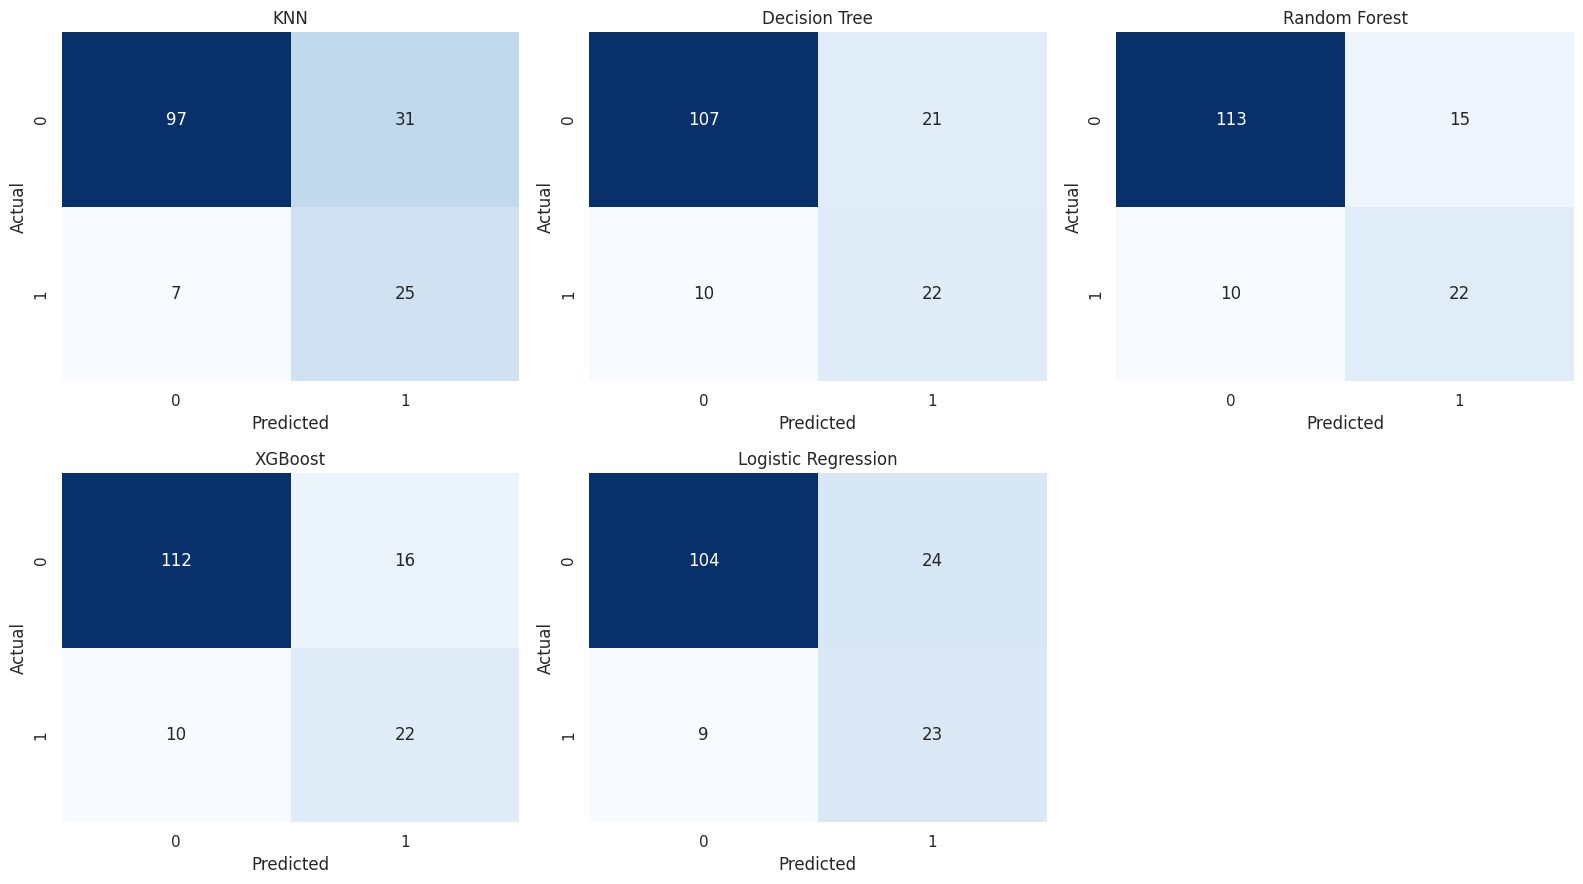

In [29]:
model_names = list(best_estimators.keys())
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_names):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(model_name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 10. ROC and Precision-Recall Curves

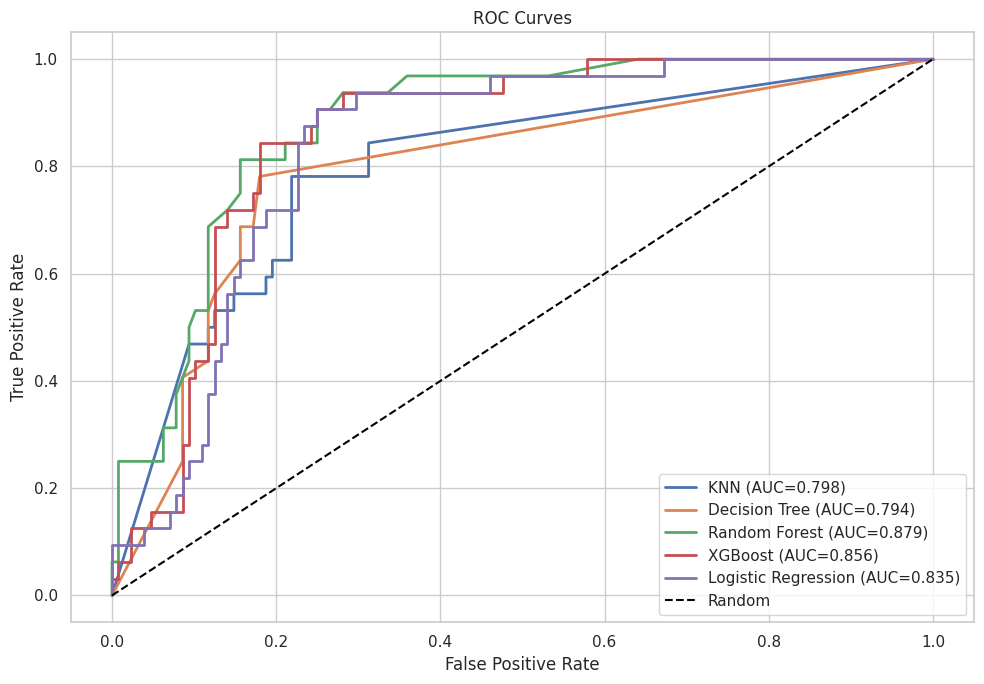

In [30]:
plt.figure(figsize=(10, 7))

for model_name in model_names:
    y_prob = probabilities[model_name]
    if y_prob is None:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    model_auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC={model_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black", label="Random")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

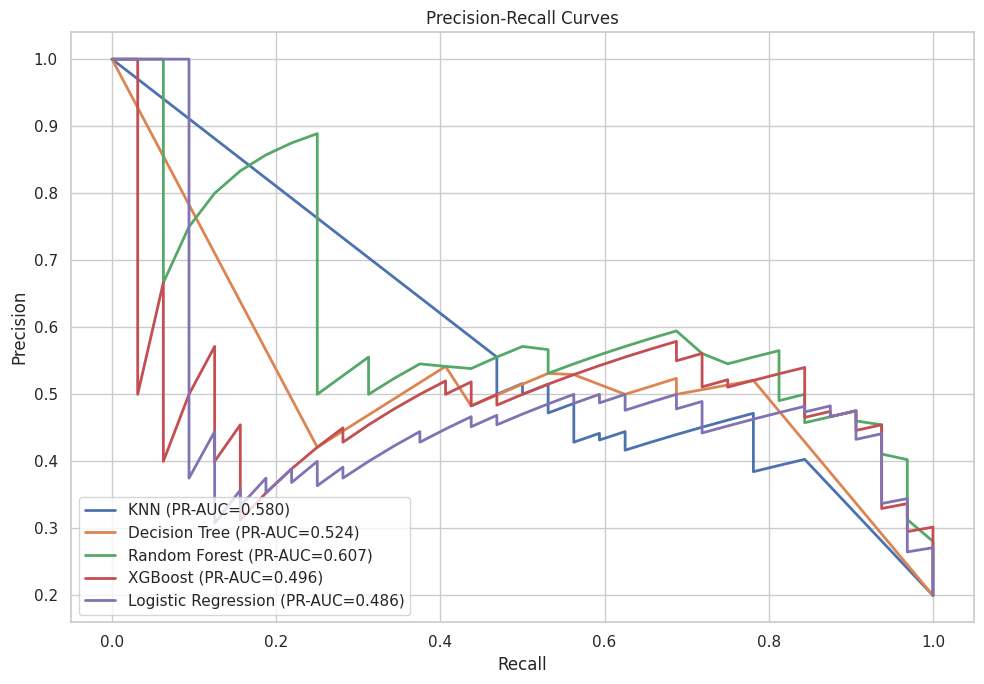

In [31]:
plt.figure(figsize=(10, 7))

for model_name in model_names:
    y_prob = probabilities[model_name]
    if y_prob is None:
        continue

    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)
    plt.plot(recall_vals, precision_vals, linewidth=2, label=f"{model_name} (PR-AUC={pr_auc:.3f})")

plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 11. Best Model Selection and Detailed Evaluation

In [32]:
# Medical-style priority: maximize recall first, then F1, then AUC
best_model_name = results_df.iloc[0]["Model"]
best_model = best_estimators[best_model_name]
y_best_pred = predictions[best_model_name]

print(f"Best model (recall-priority ranking): {best_model_name}")
print("\nClassification report:")
print(classification_report(y_test, y_best_pred))

cm_best = confusion_matrix(y_test, y_best_pred)
tn, fp, fn, tp = cm_best.ravel()

print("Confusion matrix breakdown:")
print(f"TP (Detected autism cases): {tp}")
print(f"FN (Missed autism cases): {fn}")
print(f"FP (False alarms): {fp}")
print(f"TN (Correct negatives): {tn}")

Best model (recall-priority ranking): KNN

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       128
           1       0.45      0.78      0.57        32

    accuracy                           0.76       160
   macro avg       0.69      0.77      0.70       160
weighted avg       0.84      0.76      0.78       160

Confusion matrix breakdown:
TP (Detected autism cases): 25
FN (Missed autism cases): 7
FP (False alarms): 31
TN (Correct negatives): 97


## 12. Optional Threshold Analysis for the Best Model

,Threshold,Precision,Recall,F1
0,0.10,0.402985,0.84375,0.545455
1,0.15,0.402985,0.84375,0.545455
2,0.20,0.393939,0.81250,0.530612
3,0.25,0.393939,0.81250,0.530612
4,0.30,0.396825,0.78125,0.526316


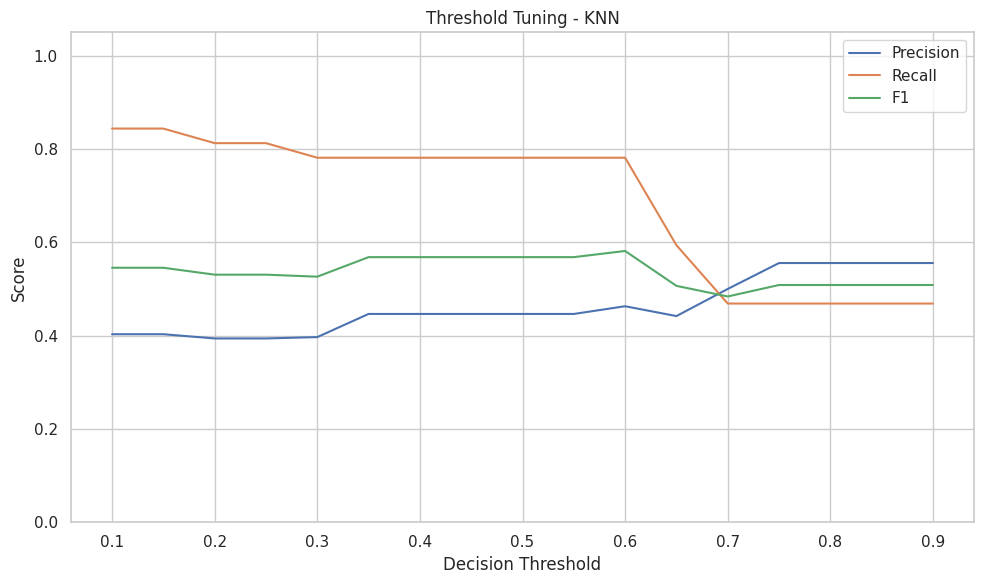

In [33]:
if probabilities[best_model_name] is not None:
    thresholds = np.linspace(0.1, 0.9, 17)
    threshold_rows = []

    for threshold in thresholds:
        y_thr = (probabilities[best_model_name] >= threshold).astype(int)
        threshold_rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_test, y_thr, zero_division=0),
            "Recall": recall_score(y_test, y_thr, zero_division=0),
            "F1": f1_score(y_test, y_thr, zero_division=0),
        })

    threshold_df = pd.DataFrame(threshold_rows)
    display(threshold_df.head())

    plt.figure(figsize=(10, 6))
    plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
    plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
    plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
    plt.title(f"Threshold Tuning - {best_model_name}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Best model does not expose probability scores.")

## 13. Save Outputs

In [34]:
with open("../models/best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

results_df.to_csv("../models/benchmark_results.csv", index=False)

print("Saved: ../models/best_model.pkl")
print("Saved: ../models/benchmark_results.csv")

Saved: ../models/best_model.pkl
Saved: ../models/benchmark_results.csv
